# Exploratory Data Analysis Starts Here:

In [12]:
# Load the cleaned dataset & import the necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tools.tools import add_constant
from scipy.stats import chi2_contingency

sns.set_style('ticks')
pd.set_option('display.max_columns', 100)

df = pd.read_csv('cleaned_data.csv')
df.info()


# PLEASE RE-READ CODES STEP-BY-STEP FOR THOROUGH CLEANING


# USE pd.cut() IN CATEGORIZING THE COLUMNS SUCH AS TotalCharges, Tenure, MonthlyCharges for Chi-square test for independence
# DONT USE NUMERICAL ENCODED VALUES FOR CHI-SQURE TEST, NUMERICALLY ENCODE APPLICABLE VARIABLES IN PREPARATION FOR VIF TEST
# HE SAME IS APPLICABLE IN BUILDING RANDOM FOREST MODEL
# LEAN YOUR CODES TO BE SUPER READABLE REM!!!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


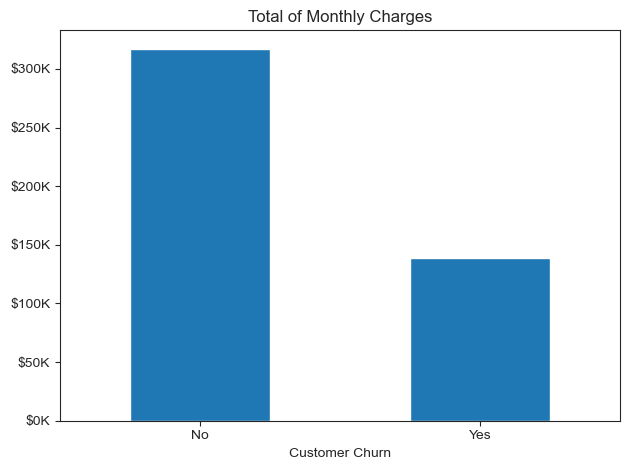

In [ ]:


# check if losing customer is costly
df_churn_cost = df.groupby('Churn')['MonthlyCharges'].sum()

fig,ax = plt.subplots(1,1)
df_churn_cost.plot(kind='bar', rot=360)
plt.title('Total of Monthly Charges')
ax.set_xlabel('Customer Churn')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.tight_layout()
plt.show()

#It turns out that almost 30% of company's monthly charges from subscription churned out.
#This indicates that we should save churners as possible.

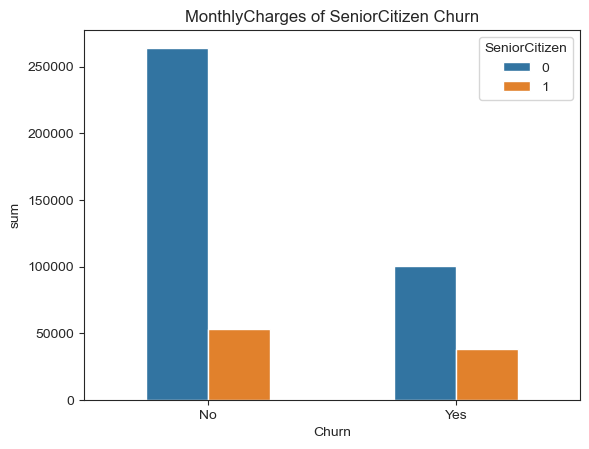

In [7]:
df_seniorcitizen = df.groupby(['SeniorCitizen', 'Churn'])['MonthlyCharges'].agg(['size', 'sum'])
sns.barplot(data=df_seniorcitizen, x='Churn', y='sum', errorbar=None, width=0.5, hue='SeniorCitizen')
plt.title('MonthlyCharges of SeniorCitizen Churn')
plt.show()

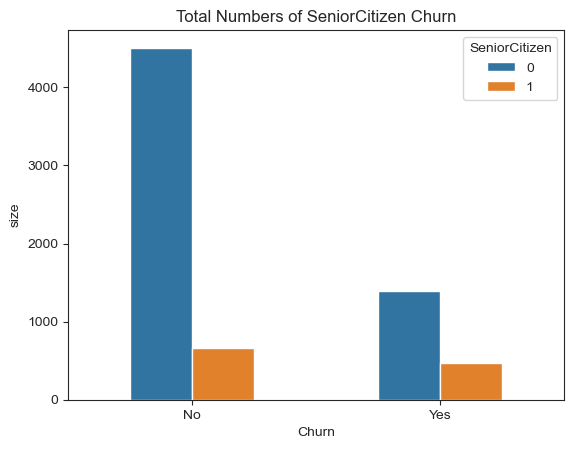

In [8]:
sns.barplot(data=df_seniorcitizen, x='Churn', y='size', errorbar=None, width=0.5, hue='SeniorCitizen')
plt.title('Total Numbers of SeniorCitizen Churn')
plt.show()

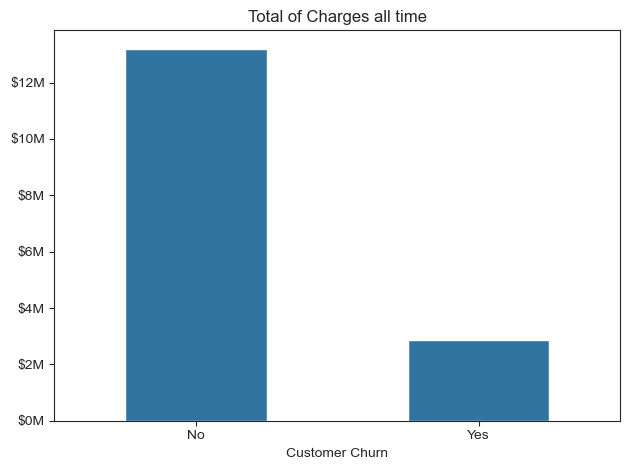

In [9]:
total_churn_cost = df.groupby('Churn')['TotalCharges'].sum()

fig,ax = plt.subplots(1,1)
sns.barplot(data=total_churn_cost, width=0.5)
ax.set_title('Total of Charges all time')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000000)}M'))
ax.set_ylabel('')
ax.set_xlabel('Customer Churn')
plt.tight_layout()
plt.show()

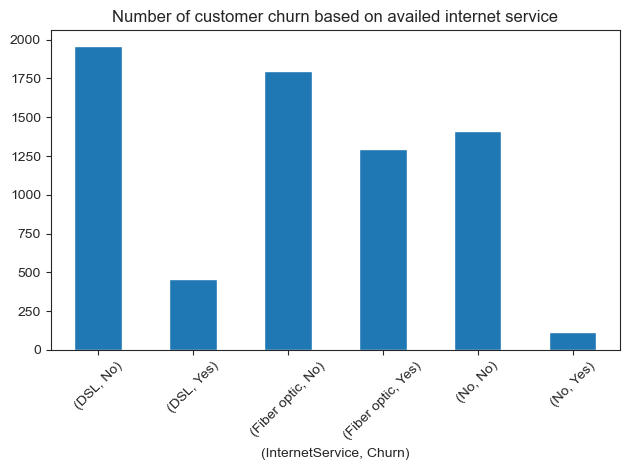

In [10]:
# Find the weak products that needs improvement.
# Number of customer churn based on their availed internet service

df_InternetService_churn = df.groupby('InternetService')['Churn'].value_counts() \
    .sort_values(ascending=False).sort_index(level='InternetService')
df_InternetService_churn.plot(kind='bar', rot=45)
plt.title('Number of customer churn based on availed internet service')
plt.xlabel('(InternetService, Churn)')
plt.tight_layout()
plt.show()

# It can be observed here a weird result where in there are more churners for Fiber optic users that DSL users
# Despite the fact that Fiber Optic is much better than DSL when it comes to speed
# This might indicate that there is some problem with the company's Fiber Optic line, such as connection reliabilty, price, etc.


In [13]:
# Quick check if InternetService really a factor:
cross_table = pd.crosstab(df['InternetService'], df['Churn'])
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(cross_table)
p_value

# Since p_value is less than 0.05, we reject null hypothesis. This indicates that there is significant relationship between InternetService and Churn.
# Consider the retaining campaign to focus on this.

9.571788222840544e-160

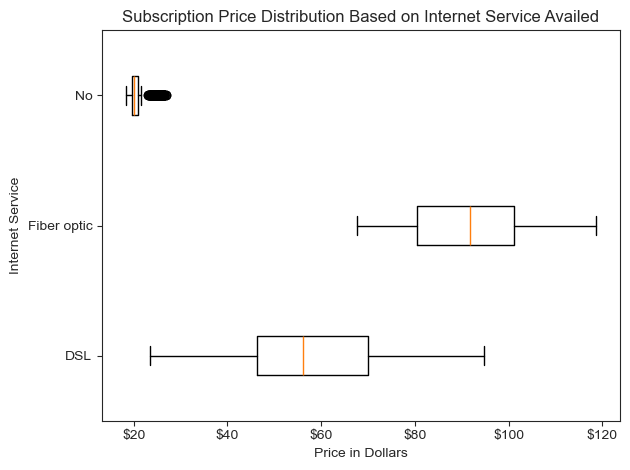

In [14]:
services = ['DSL', 'Fiber optic', 'No']
df_list = [df[df['InternetService'] == service]['MonthlyCharges'] for service in services]
plt.boxplot(data=df_list, x=df_list, tick_labels=services, vert=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x)}'))
plt.title('Subscription Price Distribution Based on Internet Service Availed')
plt.xlabel('Price in Dollars')
plt.ylabel('Internet Service')
plt.tight_layout()
plt.show()

# As observed, Fiber optic and DSL subscribers seems to be paying the normal amount (comparative to the company).
# Interestingly, many of non-internet subscriber paying more than usual set by the company.
# Hypothesis: this is one of the reasons why subscribers in this category churns.

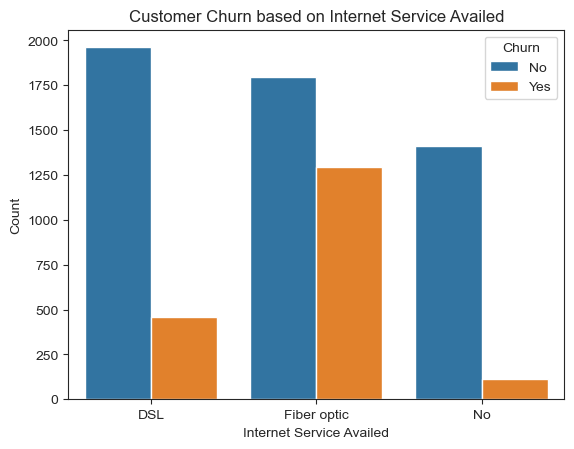

In [15]:
# get customer churn based on internet service

df_InternetService = df.groupby(['InternetService', 'Churn'])['Churn'].value_counts()
df_InternetService = df_InternetService.reset_index()
sns.barplot(data=df_InternetService, x='InternetService', y='count', hue='Churn', errorbar=None)
plt.title('Customer Churn based on Internet Service Availed')
plt.xlabel('Internet Service Availed')
plt.ylabel('Count')
plt.show()

# Interestingly, customers who do not avail internet service has the lowest churn of all even many of them paying more than the average.
# Find the reason behind this (if possible)

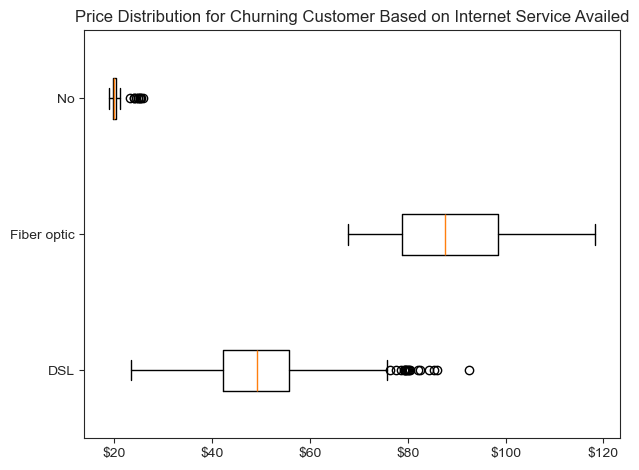

In [16]:
df_churned = df.query('Churn == "Yes"').copy()
services = ['DSL', 'Fiber optic', 'No']
df_churn_list = [df_churned[df_churned['InternetService'] == service]['MonthlyCharges'] for service in services]

plt.boxplot(data=df_churn_list, x=df_churn_list, tick_labels=services, vert=False)
plt.title('Price Distribution for Churning Customer Based on Internet Service Availed')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x)}'))
plt.tight_layout()
plt.show()

# As observed, many DSL subscribers are paying as much as those Fiber optic subscribers.
# Despite the low churn rate for 'No' category, many churners has above average monthly charges.
# So, price is still a huge factor for customer churn in this category.

In [17]:
# After seeing the last 3 graphs, it seems that price does not really matter for customer churn.
# More likely these graphs implies problem with the quality of service.
# This is because regardless of price, the customers still churn. (especially Fiber optic services, investigate this.)
# In fact, price distribution for customers who does not churn shows higher than those who churn which proves this point.

# As a solution, invest some time and money for process improvements..
# Maybe add a promo for the current subscribers as a temporary band-aid.
# Internally, give incentives to those who would come up with good processes ideas.

#Try to find other info such as cost of living of partnered couples, senior citizen, etc there's still chance that the problem lies with the demographics.